<a href="https://colab.research.google.com/github/jcmachicao/cur_MMAI__multimodal/blob/main/cur_IAMM___Laboratorio_Benchmarks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio · La lógica de cuatro benchmarks en miniatura
POPE · GAIA · τ-bench · MMMU, sin datos ni APIs externas: todo corre aquí, con `numpy` y `pandas`.

**Qué es y qué no es.**

Cada módulo reproduce la *lógica de evaluación* del benchmark (cómo se construyen las preguntas, qué cuenta como acierto, qué se reporta) sobre un mundo de juguete. Los modelos son **simulados y parametrizables**, así que los números **no son comparables** con los publicados. Sirven para ver cómo se comporta el método y, sobre todo, **dónde es ciego**.

**Estructura de cada módulo:**

(1) el protocolo,

(2) un modelo simulado y un experimento,

(3) una prueba del ciego del benchmark,

(4) ideas para experimentar.

Todos exponen una interfaz simple para que enchufes **tu propio** modelo o agente.

Cómo está armado

Cada módulo sigue la misma estructura: protocolo, modelo simulado, experimento, una prueba del ciego del benchmark e ideas para experimentar. Los modelos y agentes simulados tienen parámetros que los estudiantes pueden mover. Además, cada módulo expone una interfaz simple para enchufar uno propio (mi_modelo, mi_agente).

Módulo	Protocolo reproducido
(Lo que mostró al ejecutarlo)

* POPE	Sondeo de existencia con negativos random, popular y adversarial	El modelo que alucina por contexto cae de 0.91 a 0.75 de accuracy en el modo adversarial. El que dice "sí" a todo saca 0.50 con 100% de "sí".
* GAIA	Respuesta exacta tras encadenar herramientas, con traza	La precisión cae con el nivel (0.91, 0.80, 0.72). Con un agente que a veces adivina, sube el exact match, pero aparece acierto sin justificación.
* τ-bench	Estado final de la base, políticas permisivas y pass^k	pass^1 de 0.96 baja a 0.76 en pass^8 para el agente regular. El agente inactivo saca 0.40 sin hacer nada.
* MMMU	Opción múltiple sobre figura, con distractores con causa de error	Un modelo sin figura saca 0.35 frente a 0.25 del azar. Sesgo de posición y consistencia ante permutación quedan diagnosticados.

Hay tres hallazgos para la sesión:

* "Acierto sin justificación" (GAIA) es la misma tesis del caso policial, ahora con números propios de los estudiantes.
* La inacción premiada (τ-bench) es un ciego poco intuitivo: si la meta es "no cambiar nada", no hacer nada es éxito.
* Consistencia no es corrección. El modelo ciego de MMMU saca 1.00 de consistencia ante permutación y es poco confiable. Eso justifica por qué tus dos principios van juntos.

In [1]:
import math, re, ast, copy, operator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEMILLA = 7
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 20)

---
## Módulo 1 · POPE: ¿el modelo afirma objetos que no están?

**Lógica del benchmark:**
* convierte "¿alucina?" en una pregunta binaria, "¿hay un [objeto]?", con la mitad de objetos presentes y la mitad ausentes.
* Los ausentes se eligen de tres maneras: **random**, **popular** (los más frecuentes del dataset) y **adversarial** (los que más co-ocurren con lo presente). Reporta accuracy, precision, recall, F1 y la **proporción de "sí"**.

**Miniatura:** una "imagen" es una escena (un conjunto de objetos). El modelo simulado *percibe* bien lo que está, pero puede ser arrastrado por el contexto (`sesgo_cooc`). Para conectar un modelo real necesitarías imágenes; aquí se ejercita el protocolo.

**Interfaz:** `modelo(escena, objeto) -> bool` (¿hay ese objeto?).

Qué hacen las funciones en el módulo POPE:

* ***estadisticas(escenas)***: Calcula y devuelve un diccionario con el vocabulario de objetos, la frecuencia de cada objeto (freq), y la matriz de co-ocurrencia (co) de objetos dentro de las escenas proporcionadas.

* ***afinidad(objs, o, st)***: Determina la afinidad o 'esperabilidad' de un objeto o dada una lista de objetos objs ya presentes en una escena, utilizando las estadísticas de co-ocurrencia (st).

* ***muestrear_negativos(e, modo, k, rng, st)***: Selecciona k objetos negativos (no presentes en la escena e) de entre el vocabulario, basándose en el modo especificado ('random', 'popular', o 'adversarial') y las estadísticas st.

* ***metricas(nombre, y, yh)***: Calcula métricas de clasificación estándar como accuracy, precision, recall, F1 y el porcentaje de respuestas 'sí' (%sí), comparando las etiquetas verdaderas y con las predichas yh.

* ***evaluar_pope(modelo, escenas, st, modos, k, seed)***: Evalúa el rendimiento de un modelo (que predice la presencia de objetos) sobre un conjunto de escenas y reporta las metricas para diferentes modos de muestreo de negativos.

* ***hacer_vlm(st, percepcion, falsa_alarma, sesgo_cooc, sesgo_si, seed)***: Crea un modelo de lenguaje visual (VLM) simulado. Este modelo responde si un objeto está presente en una escena, con un comportamiento configurable a través de parámetros como la percepcion (tasa de acierto para objetos presentes), falsa_alarma (tasa de error para objetos ausentes), sesgo_cooc (sesgo basado en la co-ocurrencia) y sesgo_si (sesgo general a decir 'sí').

In [2]:
OBJETOS_POR_CONTEXTO = {
    "calle":   ["auto", "semáforo", "peatón", "bicicleta", "bus", "poste", "árbol", "banca"],
    "cocina":  ["olla", "cuchillo", "taza", "plato", "refrigeradora", "cocina a gas", "mesa", "botella"],
    "oficina": ["laptop", "teclado", "mouse", "silla", "escritorio", "taza", "lámpara", "libro"],
}

def generar_escenas(n=60, seed=SEMILLA):
    rng = np.random.default_rng(seed); ctxs = list(OBJETOS_POR_CONTEXTO); escenas = []
    for _ in range(n):
        ctx = str(rng.choice(ctxs))
        objs = {str(o) for o in rng.choice(OBJETOS_POR_CONTEXTO[ctx], size=int(rng.integers(3, 6)), replace=False)}
        if rng.random() < 0.25:   # un objeto "fuera de lugar"
            otros = [o for c in ctxs if c != ctx for o in OBJETOS_POR_CONTEXTO[c]]
            objs.add(str(rng.choice(otros)))
        escenas.append({"ctx": ctx, "objetos": objs})
    return escenas

def estadisticas(escenas):
    vocab = sorted({o for e in escenas for o in e["objetos"]})
    freq = {o: 0 for o in vocab}; co = {a: {b: 0 for b in vocab} for a in vocab}
    for e in escenas:
        for a in e["objetos"]:
            freq[a] += 1
            for b in e["objetos"]:
                if a != b: co[a][b] += 1
    return {"vocab": vocab, "freq": freq, "co": co}

def afinidad(objs, o, st):
    """Qué tan esperable es el objeto o dado lo que ya hay en la escena (lo que un modelo 'aprendió')."""
    return float(np.mean([st["co"][a][o] / st["freq"][a] for a in objs]))

def muestrear_negativos(e, modo, k, rng, st):
    ausentes = [o for o in st["vocab"] if o not in e["objetos"]]
    if modo == "random":  return [str(x) for x in rng.choice(ausentes, size=k, replace=False)]
    if modo == "popular": return sorted(ausentes, key=lambda o: -st["freq"][o])[:k]
    return sorted(ausentes, key=lambda o: -afinidad(e["objetos"], o, st))[:k]   # adversarial

def metricas(nombre, y, yh):
    y, yh = np.array(y), np.array(yh)
    tp = ((y == 1) & (yh == 1)).sum(); fp = ((y == 0) & (yh == 1)).sum()
    fn = ((y == 1) & (yh == 0)).sum(); tn = ((y == 0) & (yh == 0)).sum()
    prec = tp / (tp + fp) if tp + fp else 0.0; rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return {"modo": nombre, "accuracy": (tp + tn) / len(y), "precision": prec, "recall": rec, "F1": f1, "%sí": yh.mean()}

def evaluar_pope(modelo, escenas, st, modos=("random", "popular", "adversarial"), k=3, seed=SEMILLA):
    rng = np.random.default_rng(seed); filas = []
    for modo in modos:
        y, yh = [], []
        for e in escenas:
            pos = [str(x) for x in rng.choice(sorted(e["objetos"]), size=min(k, len(e["objetos"])), replace=False)]
            neg = muestrear_negativos(e, modo, len(pos), rng, st)
            for o in pos: y.append(1); yh.append(int(modelo(e, o)))
            for o in neg: y.append(0); yh.append(int(modelo(e, o)))
        filas.append(metricas(modo, y, yh))
    return pd.DataFrame(filas).set_index("modo")

def hacer_vlm(st, percepcion=0.95, falsa_alarma=0.03, sesgo_cooc=0.0, sesgo_si=0.0, seed=1):
    rng = np.random.default_rng(seed)
    def modelo(e, o):
        p = percepcion if o in e["objetos"] else falsa_alarma + sesgo_cooc * afinidad(e["objetos"], o, st) + sesgo_si
        return bool(rng.random() < min(max(p, 0.0), 1.0))
    return modelo

ESCENAS = generar_escenas(); ST = estadisticas(ESCENAS)
print(len(ESCENAS), "escenas |", len(ST["vocab"]), "objetos distintos")

60 escenas | 23 objetos distintos


In [8]:
for it in ESCENAS[2]:
  print(ESCENAS[2][it])

oficina
{'silla', 'libro', 'taza'}


In [10]:
ST["freq"]

{'auto': 9,
 'banca': 11,
 'bicicleta': 10,
 'botella': 12,
 'bus': 11,
 'cocina a gas': 12,
 'cuchillo': 11,
 'escritorio': 13,
 'laptop': 12,
 'libro': 13,
 'lámpara': 15,
 'mesa': 14,
 'mouse': 8,
 'olla': 10,
 'peatón': 9,
 'plato': 13,
 'poste': 8,
 'refrigeradora': 12,
 'semáforo': 6,
 'silla': 11,
 'taza': 26,
 'teclado': 12,
 'árbol': 7}

In [15]:
ST["co"]["banca"]

{'auto': 4,
 'banca': 0,
 'bicicleta': 5,
 'botella': 0,
 'bus': 8,
 'cocina a gas': 0,
 'cuchillo': 0,
 'escritorio': 1,
 'laptop': 0,
 'libro': 1,
 'lámpara': 0,
 'mesa': 0,
 'mouse': 0,
 'olla': 0,
 'peatón': 7,
 'plato': 0,
 'poste': 5,
 'refrigeradora': 0,
 'semáforo': 4,
 'silla': 1,
 'taza': 0,
 'teclado': 0,
 'árbol': 5}

In [3]:
modelos_pope = {
    "percibe bien, sin sesgo":    hacer_vlm(ST, sesgo_cooc=0.0),
    "alucina por contexto":       hacer_vlm(ST, sesgo_cooc=1.0),
    "dice 'sí' a todo":           (lambda e, o: True),
}
tabla_pope = pd.concat({n: evaluar_pope(m, ESCENAS, ST) for n, m in modelos_pope.items()})
display(tabla_pope.round(2)) if "display" in globals() else print(tabla_pope.round(2))

                                     accuracy  precision  recall    F1   %sí
                        modo                                                
percibe bien, sin sesgo random           0.95       0.95    0.94  0.95  0.50
                        popular          0.97       0.98    0.96  0.97  0.49
                        adversarial      0.97       0.98    0.95  0.97  0.48
alucina por contexto    random           0.91       0.88    0.94  0.91  0.54
                        popular          0.87       0.81    0.96  0.88  0.59
                        adversarial      0.75       0.68    0.95  0.79  0.70
dice 'sí' a todo        random           0.50       0.50    1.00  0.67  1.00
                        popular          0.50       0.50    1.00  0.67  1.00
                        adversarial      0.50       0.50    1.00  0.67  1.00


**Qué observar**
* El modelo que "alucina por contexto" cae sobre todo en **adversarial**: ahí los objetos ausentes son justo los que el contexto hace esperables. El modo importa, no solo el promedio.
* El modelo que dice "sí" a todo saca ~50% de accuracy y 100% de `%sí`. Sin esa columna, el 50% no se distinguiría de un modelo mediocre pero honesto.

**Ciego de POPE:** solo pregunta por *existencia de objetos*. No evalúa relaciones ("la taza está sobre la mesa"), atributos ni afirmaciones compuestas.

**Experimenta:** cambia `sesgo_cooc`, `percepcion` o `sesgo_si`; agrega un modo de muestreo propio; escribe `mi_modelo(escena, objeto)` y pásalo a `evaluar_pope`.

---
## Módulo 2 · GAIA: preguntas que exigen encadenar herramientas
**Lógica del benchmark:** preguntas que un humano resuelve con paciencia pero que requieren varias herramientas (búsqueda, archivos, cálculo). Cada una tiene una **respuesta final corta y no ambigua**, calificada por coincidencia casi exacta. Hay tres niveles según pasos y herramientas.

**Miniatura:** un mundo pequeño (3 plantas, una tabla de ventas), tres herramientas (`buscar`, `ventas`, `calcular`) y cinco tareas en tres niveles. Además de la respuesta, el entorno registra la **traza** de herramientas, que GAIA real no mira para calificar pero que aquí nos permite ver qué esconde el *exact match*.

**Interfaz:** `agente(tarea, env) -> str`, que usa `tarea["pregunta"]` y las herramientas de `env`.

### El Módulo GAIA: Desglosando el Procedimiento

El módulo GAIA simula un benchmark donde un agente debe responder preguntas que requieren el uso de **herramientas**. La clave es que la respuesta final debe ser **exacta** y, para nosotros, también nos interesa la **traza** de herramientas que el agente utilizó.

#### Componentes Principales:

1.  **`DOCS` y `VENTAS`**: Son las "bases de conocimiento" que las herramientas utilizan. `DOCS` contiene información textual sobre plantas, y `VENTAS` es un DataFrame de Pandas con datos de ventas.

2.  **`Entorno` Clase**: Esta clase representa el "mundo" donde opera el agente. Contiene los métodos (`buscar`, `ventas`, `calcular`) que simulan las herramientas disponibles. Cada vez que una herramienta es llamada, su uso se registra en `self.traza`.

    *   `buscar(consulta)`: Simula una búsqueda en los `DOCS`.
    *   `ventas()`: Devuelve el DataFrame `VENTAS`.
    *   `calcular(expr)`: Evalúa una expresión matemática simple de forma segura.

3.  **`sol_gX` Funciones (Agente Oráculo)**: Estas funciones (`sol_g1`, `sol_g2`, etc.) son las **soluciones de referencia**. Actúan como un "agente oráculo" que sabe exactamente qué herramientas llamar y en qué orden para resolver cada `TAREA`. Estas soluciones son las que esperamos que un agente ideal reproduzca.

4.  **`TAREAS` Lista**: Una lista de diccionarios, donde cada diccionario describe una tarea (pregunta, respuesta esperada, herramientas requeridas y la función `solucion` del oráculo).

5.  **`normalizar(s)`**: Una función auxiliar para estandarizar las respuestas (eliminar espacios, convertir a minúsculas, manejar números) y facilitar la comparación exacta.

### Ejemplo Concreto: Tarea G1

Vamos a tomar la primera tarea (`G1`) para ilustrar el proceso:

`TAREAS[0]` es:
```python
{
    'id': 'G1',
    'nivel': 1,
    'pregunta': '¿En qué año se inauguró la Planta Sur?',
    'respuesta': '2018',
    'requeridos': [('buscar', 'planta sur')],
    'solucion': sol_g1
}
```

**Procedimiento del Oráculo para G1:**

1.  Se inicializa un `Entorno` nuevo.
2.  Se llama a la función `sol_g1(env)`.
3.  Dentro de `sol_g1`, se ejecuta `env.buscar("planta sur")`. Esta herramienta busca la información de "planta sur" en `DOCS` y la devuelve. La traza del entorno registraría `('buscar', 'planta sur')`.
4.  La función `sol_g1` extrae el año "2018" de la cadena de texto y lo devuelve como la respuesta.

**Resultados Narrativos para G1:**

*   **Respuesta Oráculo**: `"2018"`
*   **Respuesta Esperada (`TAREAS[0]["respuesta"]`)**: `"2018"`
*   **Comparación**: Ambas respuestas son iguales después de la normalización, por lo tanto, el oráculo **acierta** la tarea.
*   **Traza del Entorno**: `[('buscar', 'planta sur')]`. Esto indica que el oráculo usó la herramienta `buscar` con el argumento `"planta sur"`.
*   **Requerimientos**: La tarea `G1` especifica que `[('buscar', 'planta sur')]` es una herramienta requerida. Como el oráculo la usó, su acierto está **justificado**.

In [16]:
DOCS = {
    "planta norte": "La Planta Norte fue inaugurada en 2012 y emplea a 140 personas. Su consumo anual de agua es 52000 m3.",
    "planta sur":   "La Planta Sur fue inaugurada en 2018 y emplea a 90 personas. Su consumo anual de agua es 31500 m3.",
    "planta este":  "La Planta Este fue inaugurada en 2005 y emplea a 60 personas. Su consumo anual de agua es 18000 m3.",
}
VENTAS = pd.DataFrame({"planta": ["Norte", "Sur", "Este"], "2023": [410, 250, 190], "2024": [430, 310, 185]})

_OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul, ast.Div: operator.truediv, ast.USub: operator.neg}
def calc_seguro(expr):
    def ev(n):
        if isinstance(n, ast.Constant) and isinstance(n.value, (int, float)): return n.value
        if isinstance(n, ast.BinOp) and type(n.op) in _OPS: return _OPS[type(n.op)](ev(n.left), ev(n.right))
        if isinstance(n, ast.UnaryOp) and type(n.op) in _OPS: return _OPS[type(n.op)](ev(n.operand))
        raise ValueError("expresión no permitida")
    return ev(ast.parse(expr, mode="eval").body)

class Entorno:
    """Herramientas del agente. Cada llamada queda en self.traza."""
    def __init__(self): self.traza = []
    def buscar(self, consulta):
        q = consulta.lower().strip(); self.traza.append(("buscar", q))
        for clave, texto in DOCS.items():
            if clave in q: return texto
        return "sin resultados"
    def ventas(self): self.traza.append(("ventas", "")); return VENTAS.copy()
    def calcular(self, expr): self.traza.append(("calcular", expr)); return calc_seguro(expr)
    def ejecutar(self, paso): getattr(self, paso[0])(*([paso[1]] if paso[1] else []))

anio = lambda t: int(re.search(r"inaugurada en (\d{4})", t).group(1))
emp  = lambda t: int(re.search(r"emplea a (\d+)", t).group(1))
cons = lambda t: int(re.search(r"consumo anual de agua es (\d+)", t).group(1))
def _todas(env): return {p: env.buscar(f"planta {p}") for p in ("norte", "sur", "este")}

# Soluciones de referencia (el "agente oráculo"): ejecutan las herramientas de verdad
def sol_g1(env): return str(anio(env.buscar("planta sur")))
def sol_g2(env): return str(int(env.calcular(f"{emp(env.buscar('planta norte'))}+{emp(env.buscar('planta sur'))}")))
def sol_g3(env):
    v = env.ventas(); v["crec"] = (v["2024"] - v["2023"]) / v["2023"]
    p = v.loc[v["crec"].idxmax(), "planta"].lower()
    return str(cons(env.buscar(f"planta {p}")))
def sol_g4(env):
    d = _todas(env); p = min(d, key=lambda k: anio(d[k]))
    expr = f"{cons(d[p])}/{emp(d[p])}"
    return f"{env.calcular(expr):.1f}"
def sol_g5(env):
    d = _todas(env); viejo = min(d, key=lambda k: anio(d[k])); nuevo = max(d, key=lambda k: anio(d[k]))
    return str(int(env.calcular(f"{cons(d[nuevo])}-{cons(d[viejo])}")))

B = lambda *ps: [("buscar", f"planta {p}") for p in ps]
TAREAS = [
    dict(id="G1", nivel=1, pregunta="¿En qué año se inauguró la Planta Sur?", respuesta="2018", requeridos=B("sur"), solucion=sol_g1),
    dict(id="G2", nivel=2, pregunta="¿Cuántas personas emplean en total la Planta Norte y la Planta Sur?", respuesta="230", requeridos=B("norte", "sur"), solucion=sol_g2),
    dict(id="G3", nivel=2, pregunta="¿Cuántos m3 al año consume la planta con mayor crecimiento porcentual de ventas 2023-2024?", respuesta="31500", requeridos=[("ventas", "")] + B("sur"), solucion=sol_g3),
    dict(id="G4", nivel=3, pregunta="¿Cuál es el consumo anual de agua por empleado (m3) de la planta más antigua?", respuesta="300", requeridos=B("norte", "sur", "este"), solucion=sol_g4),
    dict(id="G5", nivel=3, pregunta="¿Cuántos m3 más al año consume la planta más nueva que la más antigua?", respuesta="13500", requeridos=B("norte", "sur", "este"), solucion=sol_g5),
]

def normalizar(s):
    s = str(s).strip().lower().replace(",", "")
    try: return f"{float(s):.2f}".rstrip("0").rstrip(".")
    except ValueError: return s

# Prueba del propio benchmark: el oráculo debe acertar todo y dejar la evidencia requerida
for t in TAREAS:
    env = Entorno(); r = t["solucion"](env)
    assert normalizar(r) == normalizar(t["respuesta"]), (t["id"], r)
    assert all(p in set(env.traza) for p in t["requeridos"]), t["id"]
print("Oráculo OK en", len(TAREAS), "tareas")

Oráculo OK en 5 tareas


In [23]:
def hacer_agente_gaia(p_paso=0.9, p_suerte=0.0, seed=1):
    """Cada paso requerido sale bien con prob. p_paso. Si alguno falla, el agente responde sin evidencia completa:
       acierta 'por suerte' con prob. p_suerte, o inventa un número."""
    rng = np.random.default_rng(seed)
    def agente(tarea, env):
        ok = [rng.random() < p_paso for _ in tarea["requeridos"]]
        if all(ok): return tarea["solucion"](env)
        for paso, bien in zip(tarea["requeridos"], ok):
            if bien: env.ejecutar(paso)
        return tarea["respuesta"] if rng.random() < p_suerte else str(int(rng.integers(0, 100000)))
    return agente



In [24]:
def evaluar_gaia(agente, n=300):
    filas = []
    for t in TAREAS:
        for _ in range(n):
            env = Entorno(); r = agente(t, env)
            ok = normalizar(r) == normalizar(t["respuesta"])
            ev = all(p in set(env.traza) for p in t["requeridos"])
            filas.append(dict(nivel=t["nivel"], ok=ok, acierto_justificado=ok and ev, acierto_sin_justificacion=ok and not ev))
    return pd.DataFrame(filas).groupby("nivel").mean().round(3).rename(columns={"ok": "exact_match"})

print("Agente honesto (p_paso=0.9, nunca adivina):");  print(evaluar_gaia(hacer_agente_gaia(0.9, 0.0)))
print("\nAgente que a veces adivina (p_suerte=0.4):");   print(evaluar_gaia(hacer_agente_gaia(0.9, 0.4)))

Agente honesto (p_paso=0.9, nunca adivina):
       exact_match  acierto_justificado  acierto_sin_justificacion
nivel                                                             
1            0.907                0.907                        0.0
2            0.802                0.802                        0.0
3            0.718                0.718                        0.0

Agente que a veces adivina (p_suerte=0.4):
       exact_match  acierto_justificado  acierto_sin_justificacion
nivel                                                             
1            0.947                0.903                      0.043
2            0.878                0.802                      0.077
3            0.835                0.723                      0.112


**Qué observar**
* La precisión cae con el nivel: encadenar pasos multiplica los errores (con p=0.9 por paso, 3 pasos dan ~0.73).
* Con `p_suerte` > 0, el `exact_match` **sube**, pero la columna `acierto_sin_justificacion` muestra que parte de ese acierto no tiene evidencia detrás. Desde afuera, el benchmark no distingue un acierto razonado de uno afortunado.

**Ciego de GAIA:** califica el resultado final, no el camino. Es el mismo problema de tu caso policial: *verdad ≠ justificación*.

**Experimenta:** agrega una tarea de nivel 3 con tu propio dominio; escribe `mi_agente(tarea, env)` (por ejemplo con un LLM que decida qué herramienta llamar) y evalúalo con `evaluar_gaia`; cambia `normalizar` y observa cómo cambian los aciertos.

---
## Módulo 3 · τ-bench: agente, políticas y estado final
**Lógica del benchmark:**

Un agente atiende a un usuario con herramientas (APIs) y un **documento de políticas** que debe respetar. No se califica la conversación sino el **estado final de la base de datos** frente al estado objetivo. Su métrica distintiva es **pass^k**: probabilidad de tener éxito en **las k repeticiones** de la misma tarea, es decir, *consistencia*.

**Miniatura:**

Una tienda con 6 pedidos, tres herramientas **permisivas** (como una API real: ejecutan lo que se les pida; la política vive en el documento, no en la herramienta) y 5 tareas. En 2 de ellas la política obliga a **rechazar** al usuario. El usuario es un guion fijo, no un LLM.

**Interfaz:** `agente(tarea, tienda) -> None`; lee `tarea["solicitud"]` y modifica la base con `tienda.cancelar(...)`, `tienda.devolver(...)`, `tienda.cambiar_direccion(...)`, `tienda.consultar(...)`.

In [18]:
DB0 = {"pedidos": {
    "O1": {"estado": "procesando", "dias": 1,  "direccion": "Av. Lima 123"},
    "O2": {"estado": "entregado",  "dias": 45, "direccion": "Jr. Cusco 45"},
    "O3": {"estado": "enviado",    "dias": 3,  "direccion": "Calle Sol 9"},
    "O4": {"estado": "procesando", "dias": 2,  "direccion": "Av. Sol 77"},
    "O5": {"estado": "procesando", "dias": 2,  "direccion": "Jr. Luna 8"},
    "O6": {"estado": "entregado",  "dias": 10, "direccion": "Av. Mar 5"},
}}
POLITICAS_TEXTO = """1. Solo se puede cancelar un pedido en estado 'procesando'.
2. Solo se puede devolver un pedido 'entregado' con 30 días o menos desde la entrega.
3. Solo se puede cambiar la dirección de un pedido en estado 'procesando'.
4. Si la solicitud viola una política, rechácela y no modifique la base."""

class Tienda:
    """API permisiva: no valida políticas. Eso es responsabilidad del agente."""
    def __init__(self, db): self.db = db
    def consultar(self, oid): return dict(self.db["pedidos"][oid])
    def cancelar(self, oid): self.db["pedidos"][oid]["estado"] = "cancelado"
    def devolver(self, oid): self.db["pedidos"][oid]["estado"] = "devuelto"
    def cambiar_direccion(self, oid, nueva): self.db["pedidos"][oid]["direccion"] = nueva

def permitido(accion, p):
    if accion == "cancelar":          return p["estado"] == "procesando"
    if accion == "devolver":          return p["estado"] == "entregado" and p["dias"] <= 30
    if accion == "cambiar_direccion": return p["estado"] == "procesando"

TAREAS_TAU = [
    dict(id="T1", solicitud="Quiero cancelar mi pedido O1.", _intenciones=[("cancelar", "O1", None)], meta={"O1": {"estado": "cancelado"}}),
    dict(id="T2", solicitud="Quiero devolver el pedido O2, llegó hace mes y medio.", _intenciones=[("devolver", "O2", None)], meta={}),
    dict(id="T3", solicitud="Cambia la dirección del pedido O3 a Av. Brasil 100.", _intenciones=[("cambiar_direccion", "O3", "Av. Brasil 100")], meta={}),
    dict(id="T4", solicitud="Cancela el O4 y manda el O5 a Jr. Paz 12.", _intenciones=[("cancelar", "O4", None), ("cambiar_direccion", "O5", "Jr. Paz 12")],
         meta={"O4": {"estado": "cancelado"}, "O5": {"direccion": "Jr. Paz 12"}}),
    dict(id="T5", solicitud="Quiero devolver el pedido O6.", _intenciones=[("devolver", "O6", None)], meta={"O6": {"estado": "devuelto"}}),
]

def db_meta(t):
    db = copy.deepcopy(DB0)
    for oid, cambios in t["meta"].items(): db["pedidos"][oid].update(cambios)
    return db

def correr_tau(agente, n=20):
    exitos = {}
    for t in TAREAS_TAU:
        c = 0
        for _ in range(n):
            tienda = Tienda(copy.deepcopy(DB0)); agente(t, tienda)
            c += tienda.db == db_meta(t)
        exitos[t["id"]] = c
    return exitos

def pass_k(exitos, n, k):
    return float(np.mean([math.comb(c, k) / math.comb(n, k) for c in exitos.values()]))

def hacer_agente_tau(p_cumple=0.9, p_ejecuta=0.97, seed=1):
    """Agente simulado. Lee la intención oculta (_intenciones); un agente real debe inferirla de tarea['solicitud'].
       p_cumple: prob. de rechazar lo que viola la política. p_ejecuta: prob. de completar lo legítimo."""
    rng = np.random.default_rng(seed)
    def agente(tarea, tienda):
        for accion, oid, arg in tarea["_intenciones"]:
            if not permitido(accion, tienda.consultar(oid)) and rng.random() < p_cumple: continue   # rechaza
            if rng.random() > p_ejecuta: continue                                                    # olvida ejecutar
            getattr(tienda, accion)(oid, *([arg] if arg else []))
    return agente

inactivo = lambda tarea, tienda: None
N, KS = 20, (1, 2, 4, 8)
agentes_tau = {
    "cuidadoso (p_cumple=0.99)": hacer_agente_tau(0.99),
    "regular (p_cumple=0.90)":   hacer_agente_tau(0.90),
    "complaciente (nunca rechaza)": hacer_agente_tau(0.0),
    "inactivo (no hace nada)":   inactivo,
}
exitos_por_agente = {nombre: correr_tau(a, N) for nombre, a in agentes_tau.items()}   # una sola tanda de corridas por agente
filas = {nombre: {f"pass^{k}": pass_k(ex, N, k) for k in KS} for nombre, ex in exitos_por_agente.items()}
print(pd.DataFrame(filas).T.round(2))

                              pass^1  pass^2  pass^4  pass^8
cuidadoso (p_cumple=0.99)       0.99    0.98    0.96    0.92
regular (p_cumple=0.90)         0.96    0.92    0.86    0.76
complaciente (nunca rechaza)    0.59    0.56    0.53    0.47
inactivo (no hace nada)         0.40    0.40    0.40    0.40


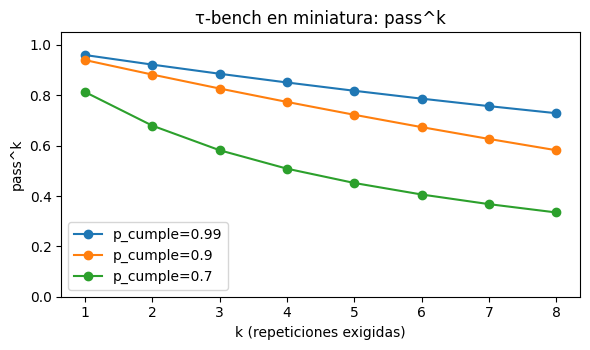

In [19]:
# Cómo decae la consistencia al exigir más repeticiones
plt.figure(figsize=(6, 3.6))
for p in (0.99, 0.90, 0.70):
    ex = correr_tau(hacer_agente_tau(p), 30)
    plt.plot(range(1, 9), [pass_k(ex, 30, k) for k in range(1, 9)], marker="o", label=f"p_cumple={p}")
plt.xlabel("k (repeticiones exigidas)"); plt.ylabel("pass^k"); plt.ylim(0, 1.05)
plt.title("τ-bench en miniatura: pass^k"); plt.legend(); plt.tight_layout(); plt.show()

**Qué observar**
* `pass^1` puede verse aceptable mientras `pass^8` se desploma: un agente que acierta "casi siempre" es poco confiable cuando la misma situación se repite. Esa es la consistencia **entre repeticiones**.
* El agente **complaciente** (hace todo lo que el usuario pide) falla justo las tareas donde la política obliga a rechazar.
* El agente **inactivo** saca ~0.4 sin hacer nada: en las tareas cuyo estado objetivo es "no cambiar nada", la inacción es un éxito. Un benchmark basado en estado final premia a quien no actúa si no se controla.

**Ciego de τ-bench (en esta miniatura):** no mira la calidad del diálogo ni los errores que no dejan huella en la base; y la política solo se ve cuando se viola de forma *observable en el estado*.

**Experimenta:** agrega una política nueva y una tarea que la ponga a prueba; inventa una tarea de rechazo parcial; escribe `mi_agente(tarea, tienda)` (con un LLM que lea `POLITICAS_TEXTO` y `tarea["solicitud"]`) y calcula su `pass^k`; cambia `n` y observa cómo el estimador se estabiliza.

---
## Módulo 4 · MMMU: preguntas de nivel experto sobre figuras
**Lógica del benchmark:**

miles de preguntas de nivel universitario, de muchas disciplinas, casi todas de **opción múltiple**, que combinan una imagen (gráfico, diagrama, tabla) con **conocimiento de la disciplina**. El acierto es la opción correcta, así que la calificación es automática.

**Miniatura:**

tres disciplinas (economía, ingeniería, salud) con una "figura" como estructura de datos y 4 opciones. Cada distractor está **construido con una causa de error** (leer mal la figura, aplicar mal el conocimiento, azar), así que los errores del modelo se pueden clasificar, igual que una taxonomía de errores.

**Interfaz:** `modelo(item) -> "A"|"B"|"C"|"D"`, donde `item` tiene `disciplina`, `figura`, `pregunta` y `opciones`.

In [20]:
LETRAS = "ABCD"

def _armar(disciplina, figura, pregunta, correcta, d_lectura, d_conoc, d_azar, rng):
    pares = [("correcta", correcta), ("lectura", d_lectura), ("conocimiento", d_conoc), ("azar", d_azar)]
    rng.shuffle(pares)
    opciones = {LETRAS[i]: t for i, (c, t) in enumerate(pares)}
    causas = {LETRAS[i]: c for i, (c, t) in enumerate(pares)}
    return dict(disciplina=disciplina, figura=figura, pregunta=pregunta, opciones=opciones,
                correcta=[l for l, c in causas.items() if c == "correcta"][0], _causas=causas)

def item_economia(rng):
    while True:
        a = int(rng.integers(80, 200)); b = a + int(rng.integers(-30, 50)); c = b + int(rng.integers(-40, 70))
        if min(a, b, c) <= 0 or c == b: continue
        corr, lect = round((c - b) / b * 100, 1), round((c - a) / a * 100, 1)       # lectura: año base equivocado
        conoc, azar = round((c - b) / c * 100, 1), round(((c - b) / b * 100) * float(rng.choice([-1.0, 1.5, 2.0])), 1)  # conocimiento: base equivocada
        if len({corr, lect, conoc, azar}) == 4: break
    f = lambda v: f"{v:.1f}%"
    fig = {"tipo": "grafico_barras", "titulo": "Ventas anuales (miles de USD)", "datos": {"2021": a, "2022": b, "2023": c}}
    return _armar("Economía", fig, "Según el gráfico, ¿cuál fue la variación porcentual de ventas entre 2022 y 2023?", f(corr), f(lect), f(conoc), f(azar), rng)

def item_ingenieria(rng):
    while True:
        V = int(rng.choice([5, 9, 12, 24])); R = [int(x) for x in rng.choice([100, 220, 330, 470, 680], size=3, replace=False)]
        s = sum(R); corr = round(1000 * V / s, 1); lect = round(1000 * V / (s - R[-1]), 1)      # lectura: omite una resistencia
        conoc = round(1000 * V * sum(1 / r for r in R), 1)                                       # conocimiento: trata la serie como paralelo
        azar = round(corr * float(rng.choice([0.5, 1.5, 2.0])), 1)
        if len({corr, lect, conoc, azar}) == 4: break
    f = lambda v: f"{v:.1f} mA"
    fig = {"tipo": "circuito_serie", "fuente_V": V, "resistencias_ohm": R}
    return _armar("Ingeniería", fig, "¿Qué corriente suministra la fuente al circuito en serie?", f(corr), f(lect), f(conoc), f(azar), rng)

ANALITOS = {"Hemoglobina (g/dL)": (12.0, 16.0), "Glucosa en ayunas (mg/dL)": (70, 99), "Potasio (mEq/L)": (3.5, 5.0)}
CLASES = ["Por debajo del rango de referencia", "Dentro del rango de referencia", "Por encima del rango de referencia"]
def _valor(rango, clase, rng):
    lo, hi = rango
    if clase == 0: return round(lo - (hi - lo) * float(rng.uniform(0.1, 0.3)), 1)
    if clase == 1: return round(float(rng.uniform(lo, hi)), 1)
    return round(hi + (hi - lo) * float(rng.uniform(0.1, 0.3)), 1)

def item_salud(rng):
    a, b = [str(x) for x in rng.choice(list(ANALITOS), size=2, replace=False)]
    ca = int(rng.integers(0, 3)); cb = int(rng.choice([c for c in range(3) if c != ca]))
    resto = [c for c in range(3) if c not in (ca, cb)][0]
    fig = {"tipo": "tabla_laboratorio", "filas": [{"analito": a, "valor": _valor(ANALITOS[a], ca, rng)}, {"analito": b, "valor": _valor(ANALITOS[b], cb, rng)}]}
    # lectura: interpreta la fila equivocada; conocimiento: invierte la dirección; azar: opción que no corresponde
    return _armar("Salud", fig, f"¿Cómo se interpreta el valor de {a}? (la tabla no incluye rangos de referencia)",
                  CLASES[ca], CLASES[cb], CLASES[resto], "Valor crítico: repetir la medición antes de interpretar", rng)

def generar_items(n_por_disciplina=20, seed=SEMILLA):
    rng = np.random.default_rng(seed)
    return [g(rng) for g in (item_economia, item_ingenieria, item_salud) for _ in range(n_por_disciplina)]

def render_figura(f):
    if f["tipo"] == "grafico_barras": return f["titulo"] + ": " + ", ".join(f"{k}={v}" for k, v in f["datos"].items())
    if f["tipo"] == "circuito_serie": return f"Fuente de {f['fuente_V']} V en serie con " + ", ".join(f"{r} Ω" for r in f["resistencias_ohm"])
    return "Laboratorio: " + "; ".join(f"{x['analito']} = {x['valor']}" for x in f["filas"])

ITEMS = generar_items()
ej = ITEMS[0]
print(f"[{ej['disciplina']}] {render_figura(ej['figura'])}\n{ej['pregunta']}")
for l, t in ej["opciones"].items(): print(f"  {l}) {t}" + ("   <- correcta" if l == ej["correcta"] else f"   (distractor: {ej['_causas'][l]})"))

[Economía] Ventas anuales (miles de USD): 2021=193, 2022=213, 2023=248
Según el gráfico, ¿cuál fue la variación porcentual de ventas entre 2022 y 2023?
  A) 16.4%   <- correcta
  B) 28.5%   (distractor: lectura)
  C) 32.9%   (distractor: azar)
  D) 14.1%   (distractor: conocimiento)


In [21]:
def _letra(item, causa): return [l for l, c in item["_causas"].items() if c == causa][0]
def _num(t):
    m = re.search(r"-?\d+(?:\.\d+)?", t); return float(m.group()) if m else None

def elegir_por_prior(item):
    """Un 'modelo ciego': sin mirar la figura, usa atajos del texto de las opciones."""
    nums = {l: _num(t) for l, t in item["opciones"].items()}
    if all(v is not None for v in nums.values()):
        return sorted(nums, key=lambda l: nums[l])[1]                                                  # la 2.ª en orden de valor (distractores suelen rodear a la correcta)
    for l, t in item["opciones"].items():
        if t.startswith("Dentro"): return l                                                              # 'lo normal' es lo más común
    return "A"

def hacer_vlm_mc(p_lectura=0.9, p_conocimiento=0.9, sesgo_A=0.0, usa_imagen=True, seed=1):
    rng = np.random.default_rng(seed)
    def modelo(item):
        if rng.random() < sesgo_A: return "A"
        if not usa_imagen: return elegir_por_prior(item)
        if rng.random() > p_lectura: return _letra(item, "lectura")
        if rng.random() > p_conocimiento: return _letra(item, "conocimiento")
        return item["correcta"]
    return modelo

def hacer_azar(seed=1):
    rng = np.random.default_rng(seed); return lambda item: str(rng.choice(list(LETRAS)))

def evaluar_mc(modelo, items):
    filas = []
    for it in items:
        r = modelo(it)
        filas.append(dict(disciplina=it["disciplina"], ok=r == it["correcta"], causa=it["_causas"][r], pos_correcta=it["correcta"]))
    return pd.DataFrame(filas)

modelos_mc = {
    "azar (25%)":              hacer_azar(),
    "ciego (sin figura)":      hacer_vlm_mc(usa_imagen=False),
    "con figura (p=0.9/0.9)":  hacer_vlm_mc(0.9, 0.9),
    "con figura, lee mal":     hacer_vlm_mc(0.6, 0.9),
    "con figura, sabe poco":   hacer_vlm_mc(0.9, 0.6),
}
res = {n: evaluar_mc(m, ITEMS) for n, m in modelos_mc.items()}
tabla = pd.DataFrame({n: r.groupby("disciplina").ok.mean() for n, r in res.items()})
tabla.loc["TOTAL"] = [r.ok.mean() for r in res.values()]
print(tabla.round(2))
print("\nCausa de los errores del modelo 'con figura, lee mal':")
print(res["con figura, lee mal"].query("not ok").causa.value_counts().to_string())

            azar (25%)  ciego (sin figura)  con figura (p=0.9/0.9)  con figura, lee mal  con figura, sabe poco
disciplina                                                                                                    
Economía          0.30                0.45                    0.75                 0.55                   0.35
Ingeniería        0.20                0.20                    0.95                 0.40                   0.65
Salud             0.25                0.40                    0.80                 0.60                   0.60
TOTAL             0.25                0.35                    0.83                 0.52                   0.53

Causa de los errores del modelo 'con figura, lee mal':
causa
lectura         26
conocimiento     3


In [22]:
# Diagnóstico 1: sesgo de posición. ¿Cambia el acierto según dónde esté la correcta?
sesgado = hacer_vlm_mc(0.9, 0.9, sesgo_A=0.4)
print("Acierto según la posición de la opción correcta")
print(pd.DataFrame({"sin sesgo": evaluar_mc(hacer_vlm_mc(0.9, 0.9), ITEMS).groupby("pos_correcta").ok.mean(),
                    "sesgo a la 'A'": evaluar_mc(sesgado, ITEMS).groupby("pos_correcta").ok.mean()}).round(2))

# Diagnóstico 2: consistencia ante permutación de opciones (mismo contenido, distinto orden)
def permutar(item, rng):
    letras = list(item["opciones"]); perm = rng.permutation(4)
    ops = {LETRAS[i]: item["opciones"][letras[perm[i]]] for i in range(4)}
    causas = {LETRAS[i]: item["_causas"][letras[perm[i]]] for i in range(4)}
    return {**item, "opciones": ops, "_causas": causas, "correcta": [l for l, c in causas.items() if c == "correcta"][0]}

def consistencia_permutacion(modelo, items, reps=5, seed=3):
    rng = np.random.default_rng(seed); out = []
    for it in items:
        elegidas = []
        for _ in range(reps):
            p = permutar(it, rng); elegidas.append(p["opciones"][modelo(p)])
        out.append(max(elegidas.count(x) for x in set(elegidas)) / reps)
    return float(np.mean(out))

print("\nConsistencia ante permutación (1.0 = siempre elige el mismo contenido):")
for n in ("ciego (sin figura)", "con figura (p=0.9/0.9)", "con figura, lee mal"):
    print(f"  {n:26s} {consistencia_permutacion(modelos_mc[n], ITEMS):.2f}")
print(f"  {'sesgo a la A':26s} {consistencia_permutacion(sesgado, ITEMS):.2f}")

Acierto según la posición de la opción correcta
              sin sesgo  sesgo a la 'A'
pos_correcta                           
A                  0.80            0.85
B                  0.83            0.50
C                  1.00            0.50
D                  0.80            0.45

Consistencia ante permutación (1.0 = siempre elige el mismo contenido):
  ciego (sin figura)         1.00
  con figura (p=0.9/0.9)     0.82
  con figura, lee mal        0.62
  sesgo a la A               0.62


**Qué observar**
* Compara `azar` con `ciego` **por disciplina**: el modelo sin figura supera el azar donde los distractores rodean al valor correcto (aquí, economía y salud) y no donde se dispersan (ingeniería). Los atajos dependen de cómo se construyen los distractores, y eso es una decisión de diseño del benchmark.
* La causa de los errores no la da el accuracy sino los distractores con causa conocida. Esa es la semilla de una taxonomía de errores.
* Un sesgo de posición se ve en la tabla por posición de la correcta. Un accuracy global lo disimula.
* La consistencia ante permutación es el mismo concepto que `pass^k`, aplicado a una perturbación irrelevante. Fíjate en el modelo ciego: es **perfectamente consistente (1.00) y poco confiable**. Consistencia no es corrección, y por eso tus dos principios van juntos.

**Ciego de MMMU:** con opción múltiple no distingue razonar de acertar por descarte, y no mira si la respuesta está fundamentada en la figura.

**Experimenta:** agrega una disciplina con su propio generador y distractores con causa; cambia cómo se construye `azar` (cercano o lejano al valor correcto) y mira qué pasa con el modelo ciego; escribe `mi_modelo(item)` (usando `render_figura(item["figura"])` como texto para un LLM).

---
## Cierre · Qué demostró cada miniatura

| Benchmark | Protocolo reproducido | Ciego demostrado | Consistencia de tu tabla |
|---|---|---|---|
| **POPE** | Sondeo binario de existencia, con tres muestreos de negativos | "Sí a todo" ≈ 50%; alucinación por contexto solo aparece en el modo adversarial | A2: afirmar solo lo sostenido por la evidencia (solo existencia de objetos) |
| **GAIA** | Respuesta final exacta tras encadenar herramientas | Acierto sin justificación: el camino no se califica | Mide capacidad, no consistencia |
| **τ-bench** | Estado final de la base frente a la meta, con `pass^k` | Premia la inacción cuando la meta es "no cambiar"; `pass^1` esconde fragilidad | B1 (políticas), B2 (estado), B3 (repeticiones) |
| **MMMU** | Opción múltiple sobre figura con conocimiento experto | Atajos sin figura; sesgo de posición | Mide comprensión; la permutación apunta a A5 |

**Pregunta para llevarse:** en cada módulo, ¿qué tendrías que definir *antes* de poder medir esa consistencia? Esa lista (qué cuenta como acierto, qué tipos de error existen, qué reglas no se pueden violar) es tu artefacto cognitivo, escrito como código.